# Maximum-likelihood estimate for mean lifetime in radiactive decay

Solve the tasks below.
For each task, give reasons for your solution by commenting in the notebook.
In conclusion, summarize your findings and contextualize them. What have you learned? Do the results make sense?

Your results will be examined for plagiarism. Please use your own plot styles, articulate your own thoughts, and present your own experimental approaches.

## Tasks

a) The maximum likelihood estimator for the mean lifetime $\tau$ of a radioactive decay described by the distribution

$$ f(t, \tau) = \frac{1}{\tau} e^{-t/\tau}$$

is given by 

$$\hat \tau = \frac{1}{n} \sum_{i=1}^n t_i.$$

The standard deviation of $\hat \tau$ can be estimated as 

$$\sigma_\tau^2 = - \left(\frac{\partial^2 \ln L(\tau)}{\partial^2 \tau} \Big|_{\tau = \hat \tau} \right)^{-1}$$

Use that to show that the uncertainty of $\hat \tau$ is given by $\sigma_\tau = \frac{\hat \tau}{\sqrt{n}}$.

b) Use the function *generate_data* defined below to generate a data set with $30$ and $300$ samples for $\tau = 2$, respectively. Plot the log-likelihood function $\ln L(\tau)$ along with the parabolic approximation. 

$$ \ln L(\tau) \approx \ln L_\mathrm{max} - \frac{(\tau - \hat \tau)^2}{2 \sigma^2}$$

What can you conclude about the validity of the approximation as the sample size increases?

c) Generate 1000 data sets each with 500 samples for $\tau = 2$ and determine for each data set whether the true value of tau lies in the interval $[\hat \tau - \sigma_{\hat \tau}, \hat \tau + \sigma_{\hat \tau}]$. How often does the true value lie in this interval? What is your expection for the correspinding probability?


### Hints

It is recommended to not start coding right away. Try to really understand how the Likelihood looks first. Realize, what the Likelihood is a function of and what it describes.


### Uncertainty of a Parameter for Maximum Likelihood Estimator
a.) Use the given information to show that the uncertainty of $\hat \tau$ is given by $\sigma_\tau = \frac{\hat \tau}{\sqrt{n}}$.


### Generating Data and Plotting log-likelihood Function
b) Use the function *generate_data* defined below to generate a data set with $30$ and $300$ samples for $\tau = 2$, respectively. Plot the log-likelihood function $\ln L(\tau)$ along with the parabolic approximation. What can you conclude about the validity of the approximtion as the sample size increases?

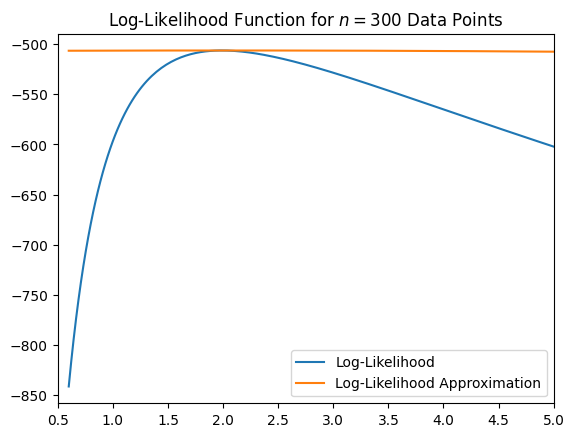

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(tau, n_samples):
    return np.random.exponential(tau, n_samples)

true_tau = 2

def exp_decay(t, tau):
    if np.any(t < 0):
        raise ValueError(f'An element in t is negative!')
    if np.any(tau == 0):
        raise ValueError(f'An element in tau is zero! Cannot divide by zero!')
    return 1/tau * np.exp(-t / tau)

# gives tau_hat, the most likely value of the parameter, given the data
def max_llh_estimator(data):
    return np.mean(data)

# likelihood is product of likelihoods of each value in data
def likelihood(tau, data):
    tau = np.atleast_1d(tau)
    data = np.atleast_1d(data)
    return np.prod(exp_decay(data[:, None], tau[None, :]), axis = 0)

# log of likelihood function is sum of the log of the likelihoods of each value in data
def log_likelihood(tau, data):
    tau = np.atleast_1d(tau)
    data = np.atleast_1d(data)
    return np.sum(np.log(exp_decay(data[:, None], tau[None, :])), axis = 0)

def log_likelihood_approx(tau, data):
    tau_hat = max_llh_estimator(data)
    sigma = np.std(data)
    log_L_max = log_likelihood(tau_hat, data)
    return log_L_max - ((tau - tau_hat)**2 / (2 * sigma**2))

n = 300
xlim = (0.5, 5)

data = generate_data(true_tau, n)
tau_grid = np.linspace(xlim[0] + 0.1, xlim[1], 200)
plt.plot(tau_grid, log_likelihood(tau_grid, data), label='Log-Likelihood')
plt.plot(tau_grid, log_likelihood_approx(tau_grid, data), label='Log-Likelihood Approximation')
plt.xlim(xlim)
plt.title(f'Log-Likelihood Function for $n = {n}$ Data Points')
plt.legend(loc = 'lower right');

### Testing for True Value in Generated Data

c) Generate 1000 data sets each with 500 samples for $\tau = 2$ and determine for each data set whether the true value of tau lies in the interval $[\hat \tau - \sigma_{\hat \tau}, \hat \tau + \sigma_{\hat \tau}]$. How often does the true value lie in this interval? What is your expection for the correspinding probability?